# Would AI discover Ophiuchus?

A simple comparison between human constellation perception and machine-based clustering using Gaia DR3 stellar data.

## Abstract

This notebook explores whether a human-defined constellation pattern can be recovered from stellar positional data using unsupervised machine learning methods.
Ophiuchus is used as a case study because it has an irregular visual shape and a strong mythological identity. The analysis compares the traditional human-defined view of Ophiuchus with clustering results based on Gaia DR3 data.

In [51]:
!pip install astroquery

In [52]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import Image, display
from PIL import Image as PILImage

from astroquery.gaia import Gaia
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, SpectralClustering

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Figures folder is ready:", FIG_DIR)

Figures folder is ready: figures


Human image ready: figures/ophiuchus_human.png


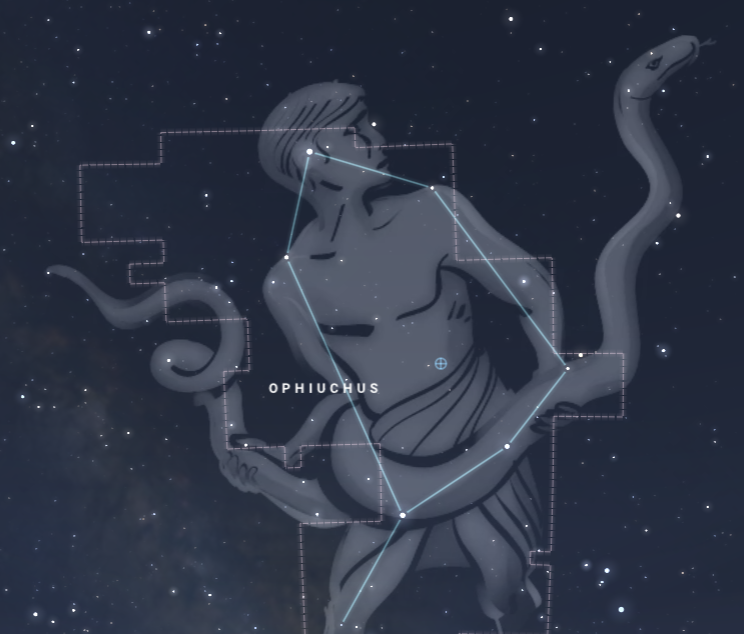

In [53]:
candidate_paths = [
    "figures/ophiuchus_human.png",
    "ophiuchus_human.png",
    "/content/figures/ophiuchus_human.png",
    "/content/ophiuchus_human.png",
    "/ophiuchus_human.png",
    "figures/figure0_ophiuchus_human.png",
    "/content/figures/figure0_ophiuchus_human.png"
]

human_image_path = None

for path in candidate_paths:
    if os.path.exists(path):
        try:
            with PILImage.open(path) as test_img:
                test_img.verify()
            human_image_path = path
            break
        except Exception:
            pass

if human_image_path is None:
    raise FileNotFoundError(
        "Stellarium image not found. Upload it as 'ophiuchus_human.png'."
    )

final_human_image = os.path.join(FIG_DIR, "ophiuchus_human.png")

if human_image_path != final_human_image:
    shutil.copy(human_image_path, final_human_image)

human_image_path = final_human_image

print("Human image ready:", human_image_path)
display(Image(filename=human_image_path, width=700))

**Figure 1.** Human-defined visualization of Ophiuchus created with Stellarium Web. The constellation figure and connecting lines are overlaid on the stellar background, showing how a symbolic pattern is placed over astronomical data.

In [54]:
query = """
SELECT
ra, dec, parallax, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 240 AND 270
AND dec BETWEEN -30 AND +10
AND phot_g_mean_mag IS NOT NULL
AND phot_g_mean_mag < 6.5
ORDER BY phot_g_mean_mag ASC
"""

job = Gaia.launch_job_async(query)
data = job.get_results()

ra = np.array(data["ra"])
dec = np.array(data["dec"])
mag = np.array(data["phot_g_mean_mag"])
parallax = np.array(data["parallax"])

print(data[:5])
print("Number of stars:", len(data))

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
        ra                 dec              parallax      phot_g_mean_mag
       deg                 deg                mas               mag      
------------------ ------------------- ------------------ ---------------
243.58621066034064  -3.694967708333353 20.411292350652413       2.0164251
   265.86794661822   4.568012245771951  39.22844495769126       2.4423249
241.35926902767926  -19.80555058042707                 --       2.5550153
249.28979755823173 -10.566976077121021  7.408845727983025       2.5565956
 257.5946814508237  -15.72447861063109                 --       2.7693226
Number of stars: 299


**Figure 2.** Bright Gaia DR3 stars in the Ophiuchus region.

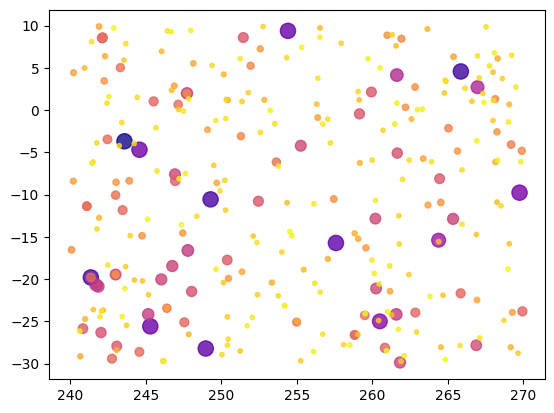

In [55]:
plt.scatter(ra, dec, s=sizes, c=mag, cmap="plasma", alpha=0.8)

**Figure 2.** Bright Gaia DR3 stars in the Ophiuchus region. The stars are shown as data points, without the traditional symbolic constellation figure.

In [56]:
X = np.vstack([ra, dec]).T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of feature matrix:", X_scaled.shape)

Shape of feature matrix: (299, 2)


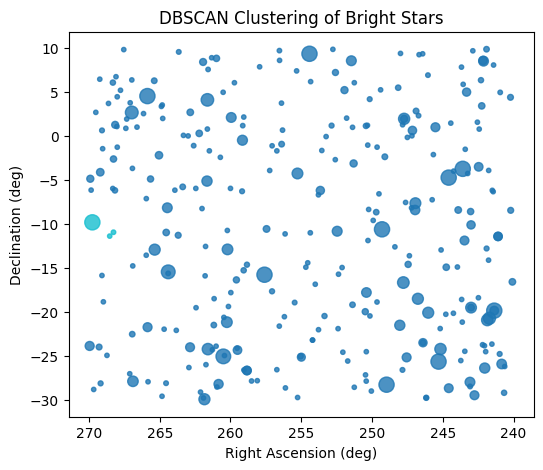

DBSCAN labels: [0 1]


In [57]:
db = DBSCAN(eps=0.28, min_samples=3)
labels_db = db.fit_predict(X_scaled)

sizes = np.clip((7 - mag) ** 2 * 8, 10, 120)

plt.figure(figsize=(6, 5))
plt.scatter(ra, dec, c=labels_db, s=sizes, cmap="tab10", alpha=0.8)

plt.gca().invert_xaxis()
plt.title("DBSCAN Clustering of Bright Stars")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")

plt.savefig(os.path.join(FIG_DIR, "figure3_dbscan.png"), dpi=300, bbox_inches="tight")
plt.show()

print("DBSCAN labels:", np.unique(labels_db))

**Figure 3.** DBSCAN clustering applied to bright Gaia DR3 stars in the Ophiuchus region. The algorithm groups stars using numerical spatial information rather than mythological or symbolic meaning.

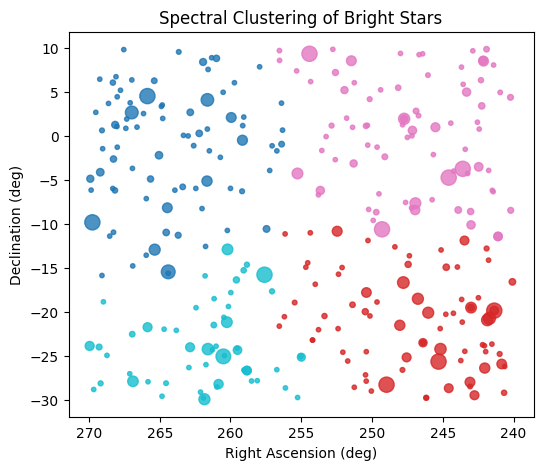

In [58]:
sc = SpectralClustering(
    n_clusters=4,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)

labels_sc = sc.fit_predict(X_scaled)

sizes = np.clip((7 - mag) ** 2 * 8, 10, 120)

plt.figure(figsize=(6, 5))
plt.scatter(ra, dec, c=labels_sc, s=sizes, cmap="tab10", alpha=0.8)

plt.gca().invert_xaxis()
plt.title("Spectral Clustering of Bright Stars")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")

plt.savefig(os.path.join(FIG_DIR, "figure4_spectral.png"), dpi=300, bbox_inches="tight")
plt.show()

**Figure 4.** Spectral Clustering applied to the same bright-star field. The data are separated into mathematical groups based on relationships between stellar positions.

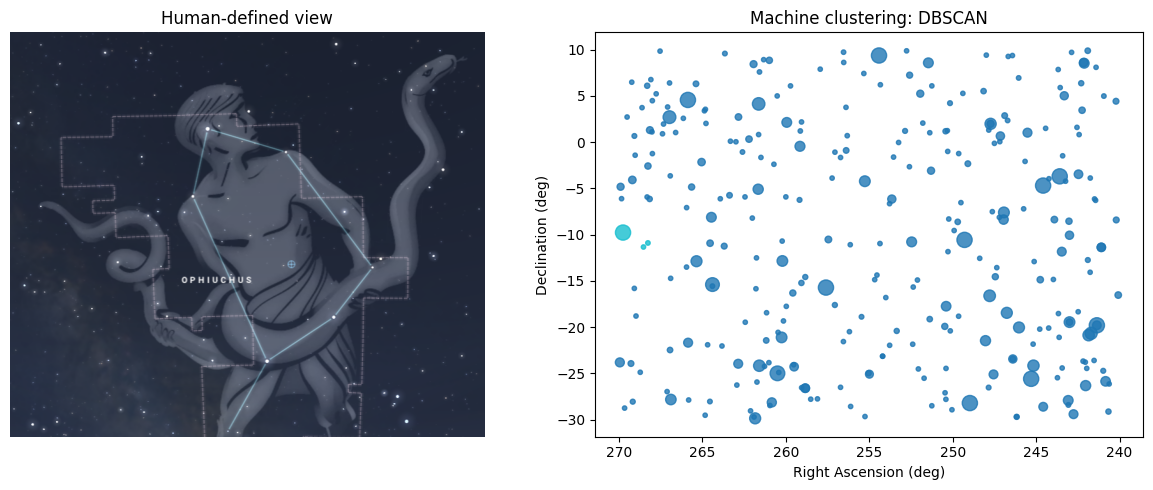

In [59]:
img = mpimg.imread(human_image_path)

sizes = np.clip((7 - mag) ** 2 * 8, 10, 120)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(img)
ax[0].axis("off")
ax[0].set_title("Human-defined view")

ax[1].scatter(ra, dec, s=sizes, c=labels_db, cmap="tab10", alpha=0.8)
ax[1].invert_xaxis()
ax[1].set_title("Machine clustering: DBSCAN")
ax[1].set_xlabel("Right Ascension (deg)")
ax[1].set_ylabel("Declination (deg)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure5_human_vs_machine.png"), dpi=300, bbox_inches="tight")
plt.show()

**Figure 5.** Comparison between the human-defined view of Ophiuchus and a machine-based clustering view of the same sky region. The Stellarium image shows the symbolic constellation figure, while the DBSCAN plot shows how bright Gaia DR3 stars are grouped using numerical spatial information.

## Discussion and Conclusion

The comparison shows that the human-defined constellation and the machine-based clustering describe the same sky region in different ways.
The Stellarium image shows Ophiuchus as a symbolic figure. The stars are connected into a recognizable pattern that comes from human history, mythology, and visual interpretation.
The machine learning results show something different. DBSCAN and Spectral Clustering do not know the story of Ophiuchus. They only process numerical information, such as stellar positions. As a result, they may detect clusters, densities, or mathematical groupings, but they do not automatically recover the traditional symbolic figure.
This does not mean that the machine finds nothing. It means that the machine is answering a different question.
AI may detect mathematical patterns in the same region of the sky, but it would not automatically discover Ophiuchus as humans defined it: as a symbolic and mythological constellation.
Ophiuchus, as a constellation, is more than a pattern in data. It is also a human interpretation of the sky.